In [1]:
import numpy as np
import cupy as cp
#import seaborn as sns
import matplotlib.pyplot as plt
import scipy
import time
#sns.set_theme()

from suppy.perturbations import PowerSeriesGradientPerturbation, AdaptiveStepGradientPerturbation
from suppy.superiorization import Superiorization
from suppy.feasibility import ExtrapolatedLandweberHyperslab, SequentialAMSHyperslab, AdaptiveStepLandweberHyperslab, SequentialWeightedAMSHyperslab
from suppy.projections import SequentialProjection,BoxProjection, MinDVHProjection, MaxDVHProjection
from suppy.feasibility import CQAlgorithm

In [2]:
import mat73

data = mat73.loadmat('HN_correct_size.mat')

#dij = data['dij']['physicalDose'][0][0][0][0]


ERROR:root:ERROR: MATLAB type not supported: DoseConstraints.matRad_MinMaxDose, (uint32)
ERROR:root:ERROR: MATLAB type not supported: DoseConstraints.matRad_MinMaxDose, (uint32)
ERROR:root:ERROR: MATLAB type not supported: DoseConstraints.matRad_MinMaxDVH, (uint32)
ERROR:root:ERROR: MATLAB type not supported: DoseConstraints.matRad_MinMaxDVH, (uint32)
ERROR:root:ERROR: MATLAB type not supported: DoseConstraints.matRad_MinMaxDose, (uint32)
ERROR:root:ERROR: MATLAB type not supported: DoseConstraints.matRad_MinMaxDVH, (uint32)
ERROR:root:ERROR: MATLAB type not supported: DoseConstraints.matRad_MinMaxDVH, (uint32)
ERROR:root:ERROR: MATLAB type not supported: DoseObjectives.matRad_MeanDose, (uint32)
ERROR:root:ERROR: MATLAB type not supported: DoseConstraints.matRad_MinMaxDose, (uint32)
ERROR:root:ERROR: MATLAB type not supported: DoseConstraints.matRad_MinMaxDose, (uint32)
ERROR:root:ERROR: MATLAB type not supported: DoseConstraints.matRad_MinMaxDose, (uint32)
ERROR:root:ERROR: MATLAB typ

In [3]:
dij = data['dij']['physicalDose'][0]
idxs = [(data['cst_resized'][i][3][0] - 1) for i in range(len(data['cst_resized']))]
labels = [data['cst_resized'][i][1] for i in range(len(data['cst_resized']))]
idxs_lengths = [len(idx) for idx in idxs]
idxs_map = dict(zip(labels,idxs))

## Set up C projections

In [4]:
organs_c = ['PTV63', 'PTV70','BRAIN_STEM_PRV', 'SPINL_CRD_PRV','SKIN', 'PAROTID_LT','PAROTID_RT', 'LARYNX']
organs_sup = ['SKIN']

In [5]:
c_bounds = {}
i = 0

for organ in organs_c:
    idxs_c = np.concatenate([idxs_map[organ] for organ in organs_c]) 
    c_bounds[organ] = (i,i+len(idxs_map[organ]))
    i += len(idxs_map[organ])
    dij_c = dij[idxs_c,:]
dij_c = cp.sparse.csr_matrix(dij_c)


# sup_bounds = {}
# i = 0
# for organ in organs_sup:
#     idxs_sup = np.concatenate([idxs_map[organ] for organ in organs_sup]) 
#     sup_bounds[organ] = (i,i+len(idxs_map[organ]))
#     i += len(idxs_map[organ])
#     dij_sup = dij[idxs_sup,:]
#     dij_sup = cp.sparse.csr_matrix(dij_sup)

In [6]:
np.unique(idxs_c).shape[0] 

print(idxs_c.shape[0], np.unique(idxs_c).shape[0])

416507 414442


In [7]:
frac = 30

dij = data['dij']['physicalDose'][0]

idxs = [(data['cst_resized'][i][3][0] - 1) for i in range(len(data['cst_resized']))]

labels = [data['cst_resized'][i][1] for i in range(len(data['cst_resized']))]
idxs_lengths = [len(idx) for idx in idxs]
idxs_map = dict(zip(labels,idxs))


organs_c = ['PTV63', 'PTV70','BRAIN_STEM_PRV', 'SPINL_CRD_PRV','PAROTID_LT','PAROTID_RT', 'LARYNX', 'SKIN']
organs_sup = ['SKIN']
c_bounds = {}
i = 0

for organ in organs_c:
    c_bounds[organ] = (i,i+len(idxs_map[organ]))
    i += len(idxs_map[organ])
idxs_c = np.concatenate([idxs_map[organ] for organ in organs_c])


dij_c = dij[idxs_c,:]
dij_c = cp.sparse.csr_matrix(dij_c)

d_min_c = cp.zeros(dij_c.shape[0])
d_min_c[c_bounds['PTV63'][0]:c_bounds['PTV63'][1]] = 61
d_min_c[c_bounds['PTV70'][0]:c_bounds['PTV70'][1]] = 68

d_min_c = d_min_c / frac

d_max_c = cp.ones(dij_c.shape[0])
d_max_c[c_bounds['PTV63'][0]:c_bounds['PTV63'][1]] = 65
d_max_c[c_bounds['PTV70'][0]:c_bounds['PTV70'][1]] = 72
d_max_c[c_bounds['BRAIN_STEM_PRV'][0]:c_bounds['BRAIN_STEM_PRV'][1]] = 30
d_max_c[c_bounds['SPINL_CRD_PRV'][0]:c_bounds['SPINL_CRD_PRV'][1]] = 40
d_max_c[c_bounds['PAROTID_LT'][0]:c_bounds['PAROTID_LT'][1]] = 40
d_max_c[c_bounds['PAROTID_RT'][0]:c_bounds['PAROTID_RT'][1]] = 40
d_max_c[c_bounds['LARYNX'][0]:c_bounds['LARYNX'][1]] = 40
d_max_c[c_bounds['SKIN'][0]:c_bounds['SKIN'][1]] = 65

d_max_c = d_max_c / frac

In [8]:
weights = cp.ones(dij_c.shape[0])
weights[c_bounds['PTV63'][0]:c_bounds['PTV63'][1]] = 10/len(idxs_map['PTV63'])
weights[c_bounds['PTV70'][0]:c_bounds['PTV70'][1]] = 10/len(idxs_map['PTV70'])
for organ in ['BRAIN_STEM_PRV', 'SPINL_CRD_PRV','SKIN', 'PAROTID_LT','PAROTID_RT', 'LARYNX']:
    weights[c_bounds[organ][0]:c_bounds[organ][1]] = 1/len(idxs_map[organ])
weights = weights/weights.sum()


alg_al = AdaptiveStepLandweberHyperslab(dij_c,d_min_c,d_max_c,weights = weights)
c_alg_al = SequentialProjection([alg_al,BoxProjection(0,cp.inf)])

alg_al_2 = AdaptiveStepLandweberHyperslab(dij_c,d_min_c,d_max_c)
c_alg_al_2 = SequentialProjection([alg_al_2,BoxProjection(0,cp.inf)])


## Q Projections

In [9]:
organs_q = ['PAROTID_LT','PAROTID_RT','BRAIN_STEM_PRV', 'SPINL_CRD_PRV', 'LARYNX']
q_bounds = {}
i = 0
for organ in organs_q:
    idxs_q = np.concatenate([idxs_map[organ] for organ in organs_q]) 
    q_bounds[organ] = (i,i+len(idxs_map[organ]))
    i += len(idxs_map[organ])
    dij_q = dij[idxs_q,:]
    dij_q = cp.sparse.csr_matrix(dij_q)

# set up Q Projections
frac = 30
q_proj_parotid_lt = MaxDVHProjection(10/frac,0.05,idx = cp.arange(q_bounds['PAROTID_LT'][0],q_bounds['PAROTID_LT'][1]))

q_proj_parotid_rt = MaxDVHProjection(10/frac,0.05,idx = cp.arange(q_bounds['PAROTID_RT'][0],q_bounds['PAROTID_RT'][1]))

q_proj_brain_stem = MaxDVHProjection(10/frac,0.05,idx = cp.arange(q_bounds['BRAIN_STEM_PRV'][0],q_bounds['BRAIN_STEM_PRV'][1]))

q_proj_spinal_cord = MaxDVHProjection(10/frac,0.05,idx = cp.arange(q_bounds['SPINL_CRD_PRV'][0],q_bounds['SPINL_CRD_PRV'][1]))

q_proj_larynx = MaxDVHProjection(10/frac,0.05,idx = cp.arange(q_bounds['LARYNX'][0],q_bounds['LARYNX'][1]))

q_alg = SequentialProjection([q_proj_parotid_lt, q_proj_parotid_rt, q_proj_brain_stem, q_proj_spinal_cord, q_proj_larynx])

In [10]:
full_alg_al = CQAlgorithm(dij_q,c_alg_al,q_alg,algorithmic_relaxation= 1.9/(dij_q.data**2).sum())

### Solve for CQ Algorithm

In [11]:
t_start = time.time()
sol_500 = full_alg_al.solve(cp.zeros(dij_q.shape[1]),max_iter=500,proximity_measures=[("p_norm", 2), "max_norm"],prox_tol = 1e-9,del_prox_tol = 1e-12,del_prox_n = 10)   
t_end = time.time()
print(f"Time for 500 iters of full AL: {t_end - t_start} seconds")

Time for 500 iters of full AL: 20.58866310119629 seconds


In [12]:
t_start = time.time()
sol_2500 = full_alg_al.solve(cp.zeros(dij_q.shape[1]),max_iter=2500,proximity_measures=[("p_norm", 2), "max_norm"],prox_tol = 1e-9,del_prox_tol = 1e-12,del_prox_n = 10)   
t_end = time.time()
print(f"Time for 2500 iters of full AL: {t_end - t_start} seconds")

Time for 2500 iters of full AL: 108.20132350921631 seconds


## Add superiorization to CQ


In [13]:
from suppy.perturbations import PowerSeriesGradientPerturbation, AdaptiveStepGradientPerturbation
from suppy.superiorization import Superiorization, SplitSuperiorization


class SquaredDeviation():
    def __init__(self, d_ref:float, idxs: list):
        self.d_ref = d_ref
        self.idxs = idxs
        self.length = self.idxs.sum() if self.idxs.dtype == bool else len(self.idxs)


    def objective_value(self, x: cp.ndarray) -> float:
        diff = x[self.idxs] - self.d_ref
        return 1/self.length* (diff@diff)
    
    def objective_gradient(self, x: cp.ndarray) -> cp.ndarray:
        xp = cp if isinstance(x, cp.ndarray) else np
        grad = xp.zeros(x.shape[0])
        grad[self.idxs] = 2*(x[self.idxs] - self.d_ref)
        return 1/self.length*grad
    
class SquaredOverdosing():
    def __init__(self, d_ref:float, idxs: list):
        self.d_ref = d_ref
        self.idxs = idxs
        self.length = self.idxs.sum() if self.idxs.dtype == bool else len(self.idxs)

    def objective_value(self, x: cp.ndarray) -> float:
        d_diff = x[self.idxs] - self.d_ref
        d_diff[d_diff < 0] = 0
        return 1/self.length*(d_diff@d_diff)
        
    def objective_gradient(self, x: cp.ndarray) -> cp.ndarray:
        xp = cp if isinstance(x, cp.ndarray) else np
        grad = xp.zeros(x.shape[0])
        d_diff = x[self.idxs] - self.d_ref
        d_diff[d_diff < 0] = 0
        grad[self.idxs] = 2*d_diff
        return 1/self.length*grad

    
class MeanDose():
    def __init__(self, idxs: list):
        self.idxs = idxs
        self.length = self.idxs.sum() if self.idxs.dtype == bool else len(self.idxs)

    def objective_value(self, x: cp.ndarray) -> float:
        return 1/self.length*((x[self.idxs]).sum())
    
    def objective_gradient(self, x: cp.ndarray) -> cp.ndarray:
        xp = cp if isinstance(x, cp.ndarray) else np
        grad = xp.zeros(x.shape[0])
        grad[self.idxs] = 1/self.length*np.ones(self.length)
        return grad
    

class objectives():
    def __init__(self,objectives: list, penalties: list,dij):
        self.objectives = objectives 
        self.penalties = penalties
        self.dij = dij

    def objective_value(self, x: cp.ndarray) -> float:
        d = self.dij @ x
        return sum([f.objective_value(d)*p for f,p in zip(self.objectives,self.penalties)])
    
    def objective_gradient(self, x: cp.ndarray) -> cp.ndarray:
        d = self.dij @ x
        return sum([f.objective_gradient(d)*p for f,p in zip(self.objectives,self.penalties)])@self.dij




In [14]:
objs = objectives([MeanDose(cp.arange(c_bounds['SKIN'][0],c_bounds['SKIN'][1]))],[100], dij_c)
pert_power_law = PowerSeriesGradientPerturbation(objs.objective_value, objs.objective_gradient,n_restart = 500,step_size = 0.99)
alg_sup_power_law = SplitSuperiorization(full_alg_al,input_perturbation_scheme = pert_power_law)


In [15]:
# objs_2 = objectives([MeanDose(cp.arange(len(idxs_map['SKIN'])))],[100], dij_sup)
# pert_power_law = PowerSeriesGradientPerturbation(objs_2.objective_value, objs_2.objective_gradient,n_restart = 500,step_size = 0.99)
# alg_sup_power_law = SplitSuperiorization(full_alg_al,input_perturbation_scheme = pert_power_law)


In [16]:
t_start = time.time()
sol_sup_power_law_500 = alg_sup_power_law.solve(cp.zeros(dij_q.shape[1]), max_iter = 500)
t_end = time.time()
print(f"Time for 500 iters of superiorized power law: {t_end - t_start} seconds")

Time for 500 iters of superiorized power law: 49.29685091972351 seconds


In [17]:
t_start = time.time()
sol_sup_power_law_2500= alg_sup_power_law.solve(cp.zeros(dij_q.shape[1]), max_iter = 2500)
t_end = time.time()
print(f"Time for 2500 iters of superiorized power law: {t_end - t_start} seconds")

Time for 2500 iters of superiorized power law: 270.8480463027954 seconds


## Run with only linear constraints

In [18]:
d_min_linear = cp.zeros(dij_c.shape[0])
d_min_linear[c_bounds['PTV63'][0]:c_bounds['PTV63'][1]] = 61
d_min_linear[c_bounds['PTV70'][0]:c_bounds['PTV70'][1]] = 68

d_max_linear = cp.ones(dij_c.shape[0])
d_max_linear[c_bounds['PTV63'][0]:c_bounds['PTV63'][1]] = 65
d_max_linear[c_bounds['PTV70'][0]:c_bounds['PTV70'][1]] = 72
d_max_linear[c_bounds['BRAIN_STEM_PRV'][0]:c_bounds['BRAIN_STEM_PRV'][1]] = 10
d_max_linear[c_bounds['SPINL_CRD_PRV'][0]:c_bounds['SPINL_CRD_PRV'][1]] = 10
d_max_linear[c_bounds['PAROTID_LT'][0]:c_bounds['PAROTID_LT'][1]] = 10
d_max_linear[c_bounds['PAROTID_RT'][0]:c_bounds['PAROTID_RT'][1]] = 10
d_max_linear[c_bounds['LARYNX'][0]:c_bounds['LARYNX'][1]] = 10
d_max_linear[c_bounds['SKIN'][0]:c_bounds['SKIN'][1]] = 65

d_min_linear = d_min_linear / frac
d_max_linear = d_max_linear / frac

In [19]:
weights = cp.ones(dij_c.shape[0])
weights[c_bounds['PTV63'][0]:c_bounds['PTV63'][1]] = 10/len(idxs_map['PTV63'])
weights[c_bounds['PTV70'][0]:c_bounds['PTV70'][1]] = 10/len(idxs_map['PTV70'])
for organ in ['BRAIN_STEM_PRV', 'SPINL_CRD_PRV','SKIN', 'PAROTID_LT','PAROTID_RT', 'LARYNX']:
    weights[c_bounds[organ][0]:c_bounds[organ][1]] = 1/len(idxs_map[organ])
weights = weights/weights.sum()


alg_al_linear= AdaptiveStepLandweberHyperslab(dij_c,d_min_linear,d_max_linear,weights = weights)
c_alg_al_linear = SequentialProjection([alg_al_linear,BoxProjection(0,cp.inf)])


## Run with linear constraints

In [20]:
t_start = time.time()
sol_linear_500 = c_alg_al_linear.solve(cp.zeros(dij_q.shape[1]),max_iter=500,proximity_measures=[("p_norm", 2), "max_norm"],prox_tol = 1e-9,del_prox_tol = 1e-12,del_prox_n = 10)
t_end = time.time()
print(f"Time for 500 iters of linear AL: {t_end - t_start} seconds")

Time for 500 iters of linear AL: 22.45062518119812 seconds


In [21]:
t_start = time.time()
sol_linear_2500 = c_alg_al_linear.solve(cp.zeros(dij_q.shape[1]),max_iter=2500,proximity_measures=[("p_norm", 2), "max_norm"],prox_tol = 1e-9,del_prox_tol = 1e-12,del_prox_n = 10)
t_end = time.time()
print(f"Time for 2500 iters of linear AL: {t_end - t_start} seconds")

Time for 2500 iters of linear AL: 100.60992980003357 seconds


## Superiorization

In [22]:
alg_sup_linear = Superiorization(c_alg_al_linear,perturbation_scheme = pert_power_law)

In [23]:
t_start = time.time()
sol_sup_linear_500 = alg_sup_linear.solve(cp.zeros(dij_q.shape[1]), max_iter = 500)
t_end = time.time()
print(f"Time for 500 iters of superiorized linear: {t_end - t_start} seconds")

Time for 500 iters of superiorized linear: 54.31186509132385 seconds


In [24]:
t_start = time.time()
sol_sup_linear_2500 = alg_sup_linear.solve(cp.zeros(dij_q.shape[1]), max_iter = 2500)
t_end = time.time()
print(f"Time for 2500 iters of superiorized linear: {t_end - t_start} seconds")

Time for 2500 iters of superiorized linear: 261.6252017021179 seconds


# Evaluation

In [25]:
new_idxs = []
organs_c = ['PTV63', 'PTV70','BRAIN_STEM_PRV', 'SPINL_CRD_PRV','SKIN', 'PAROTID_LT','PAROTID_RT', 'LARYNX']

for el in organs_c:
    new_idxs.append(idxs_map[el].astype(int))

In [26]:
data = scipy.io.loadmat('HN_solution_infeasible_larynx_final.mat')
sol_matRad_optimized_infeasible = data['resultGUI']['w'][0][0].T[0]

data = scipy.io.loadmat('opti.mat')

sol_matRad_optimized_comparison = data['resultGUI']['w'][0][0].T[0]

### DVH comparison for CQ superiorization, feasibility seeking and optimization

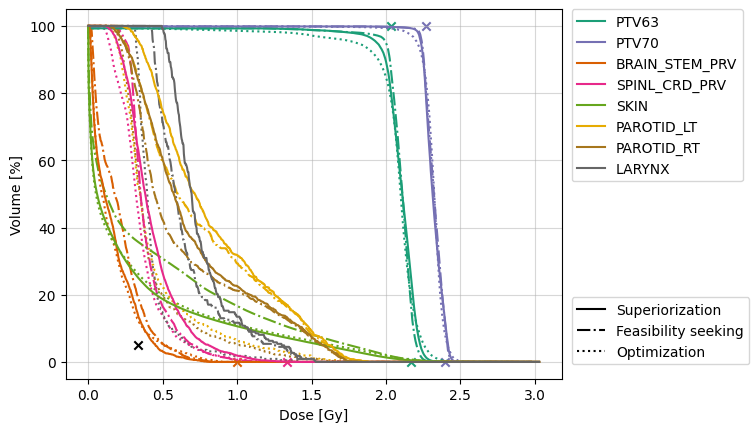

In [27]:
from suppy.utils import calc_dvh
colors = ['#1b9e77','#7570b3','#d95f02','#e7298a','#66a61e','#e6ab02','#a6761d','#666666']
 
fig,ax = plt.subplots()

# MatRad optimized
a,b = calc_dvh(dij@sol_matRad_optimized_comparison, new_idxs)

for i,(el,label) in enumerate(zip(a,organs_c)):
    ax.plot(b,el*100,color = colors[i],linestyle = ':')

# Feasibility seeking
a,b = calc_dvh(dij@sol_2500.get(), new_idxs)

for i,(el,label) in enumerate(zip(a,organs_c)):#
    ax.plot(b,el*100,color = colors[i],linestyle = '-.')



p1 = ax.plot(0,0,label = r'Superiorization', color = 'k',linestyle = '-')
p2 = ax.plot(0,0,label = r'Feasibility seeking', color = 'k',linestyle = '-.')
p3 = ax.plot(0,0,label = r'Optimization', color = 'k',linestyle = ':')
handles = [p1[0], p2[0], p3[0]]
legend2 = plt.legend(handles=handles, loc="upper left", bbox_to_anchor=(1.02, 0.02 ,0.3, 0.2), borderaxespad=0)


a,b = calc_dvh(dij@sol_sup_power_law_2500.get(), new_idxs)
handles = []
for i,(el,label) in enumerate(zip(a,organs_c)):
    handles.append(ax.plot(b,el*100,color = colors[i],linestyle = '-',label = label)[0])
legend1 = ax.legend(handles=handles, loc="upper left", bbox_to_anchor=(1.02, 0.8, 0.3, 0.2), borderaxespad=0)
ax.add_artist(legend2)


bbox1 = legend1.get_window_extent(fig.canvas.get_renderer())
bbox2 = legend2.get_window_extent(fig.canvas.get_renderer())

max_width = max(bbox1.width, bbox2.width)


plt.scatter(30/frac,0,marker = 'x',color = colors[2])
plt.scatter(40/frac,0,marker = 'x',color = colors[3])
plt.scatter(65/frac,0,marker = 'x',color = colors[0])
plt.scatter(61/frac,100,marker = 'x',color = colors[0])
plt.scatter(10/frac,5,marker = 'x',color = 'k')
plt.scatter(68/frac,100,marker = 'x',color = colors[1])
plt.scatter(72/frac,0,marker = 'x',color = colors[1])

plt.xlabel('Dose [Gy]')
plt.ylabel('Volume [%]')
plt.grid(alpha = 0.5)


plt.savefig('HN_superiorization_vs_optimization_vs_feasibility_seeking_30_fractions_new_colors.png', bbox_inches='tight', dpi = 600)
#plt.xlim(right = 80)

### DVH comparison for 500 and 2500 iterations feasibility seeking

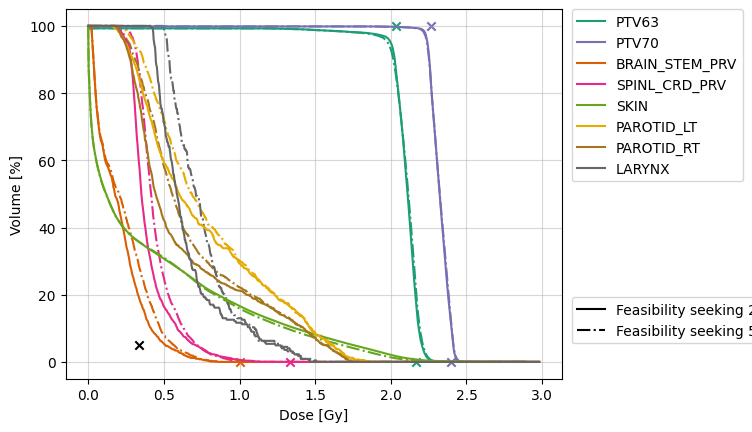

In [28]:
from suppy.utils import calc_dvh
colors = ['#1b9e77','#7570b3','#d95f02','#e7298a','#66a61e','#e6ab02','#a6761d','#666666']
plt.close()
fig,ax = plt.subplots()

a,b = calc_dvh(dij@sol_500.get(), new_idxs)

for i,(el,label) in enumerate(zip(a,organs_c)):
    ax.plot(b,el*100,color = colors[i],linestyle = '-.')



p1 = ax.plot(0,0,label = r'Feasibility seeking 2500', color = 'k',linestyle = '-')
p3 = ax.plot(0,0,label = r'Feasibility seeking 500', color = 'k',linestyle = '-.')
handles = [p1[0], p3[0]]
legend2 = plt.legend(handles=handles, loc="upper left", bbox_to_anchor=(1.02, 0.02 ,0.3, 0.2), borderaxespad=0)

a,b = calc_dvh(dij@sol_2500.get(), new_idxs)
handles = []
for i,(el,label) in enumerate(zip(a,organs_c)):
    handles.append(ax.plot(b,el*100,color = colors[i],linestyle = '-',label = label)[0])
legend1 = ax.legend(handles=handles, loc="upper left", bbox_to_anchor=(1.02, 0.8, 0.3, 0.2), borderaxespad=0)
ax.add_artist(legend2)


bbox1 = legend1.get_window_extent(fig.canvas.get_renderer())
bbox2 = legend2.get_window_extent(fig.canvas.get_renderer())

max_width = max(bbox1.width, bbox2.width)



plt.scatter(30/frac,0,marker = 'x',color = colors[2])
plt.scatter(40/frac,0,marker = 'x',color = colors[3])
plt.scatter(65/frac,0,marker = 'x',color = colors[0])
plt.scatter(61/frac,100,marker = 'x',color = colors[0])
plt.scatter(10/frac,5,marker = 'x',color = 'k')
plt.scatter(68/frac,100,marker = 'x',color = colors[1])
plt.scatter(72/frac,0,marker = 'x',color = colors[1])

plt.xlabel('Dose [Gy]')
plt.ylabel('Volume [%]')
plt.grid(alpha = 0.5)


plt.savefig('HN_comparison_DVH_500_2500_feasibility_30_fractions_new_colors.png', bbox_inches='tight', dpi = 600)
#plt.xlim(right = 80)

### DVH comparison for 500 and 2500 iterations superiorization

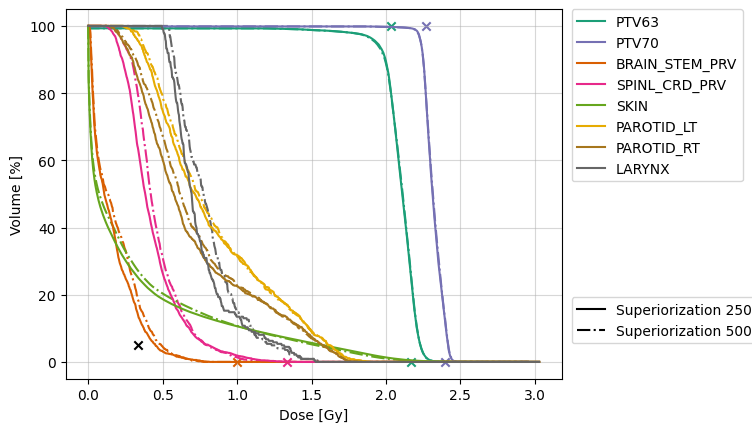

In [29]:
from suppy.utils import calc_dvh
colors = ['#1b9e77','#7570b3','#d95f02','#e7298a','#66a61e','#e6ab02','#a6761d','#666666']

plt.close()
fig,ax = plt.subplots()

a,b = calc_dvh(dij@sol_sup_power_law_500.get(), new_idxs)

for i,(el,label) in enumerate(zip(a,organs_c)):
    ax.plot(b,el*100,color = colors[i],linestyle = '-.')



p1 = ax.plot(0,0,label = r'Superiorization 2500', color = 'k',linestyle = '-')
p3 = ax.plot(0,0,label = r'Superiorization 500', color = 'k',linestyle = '-.')
handles = [p1[0], p3[0]]
legend2 = plt.legend(handles=handles, loc="upper left", bbox_to_anchor=(1.02, 0.02 ,0.3, 0.2), borderaxespad=0)

a,b = calc_dvh(dij@sol_sup_power_law_2500.get(), new_idxs)
handles = []
for i,(el,label) in enumerate(zip(a,organs_c)):
    handles.append(ax.plot(b,el*100,color = colors[i],linestyle = '-',label = label)[0])
legend1 = ax.legend(handles=handles, loc="upper left", bbox_to_anchor=(1.02, 0.8, 0.3, 0.2), borderaxespad=0)
ax.add_artist(legend2)


bbox1 = legend1.get_window_extent(fig.canvas.get_renderer())
bbox2 = legend2.get_window_extent(fig.canvas.get_renderer())

max_width = max(bbox1.width, bbox2.width)



plt.scatter(30/frac,0,marker = 'x',color = colors[2])
plt.scatter(40/frac,0,marker = 'x',color = colors[3])
plt.scatter(65/frac,0,marker = 'x',color = colors[0])
plt.scatter(61/frac,100,marker = 'x',color = colors[0])
plt.scatter(10/frac,5,marker = 'x',color = 'k')
plt.scatter(68/frac,100,marker = 'x',color = colors[1])
plt.scatter(72/frac,0,marker = 'x',color = colors[1])

plt.xlabel('Dose [Gy]')
plt.ylabel('Volume [%]')
plt.grid(alpha = 0.5)


plt.savefig('HN_comparison_DVH_500_2500_superiorization_30_fractions_new_colors.png', bbox_inches='tight', dpi = 600)
#plt.xlim(right = 80)

### DVH comparison for 500 and 2500 iterations linear feasibility seeking

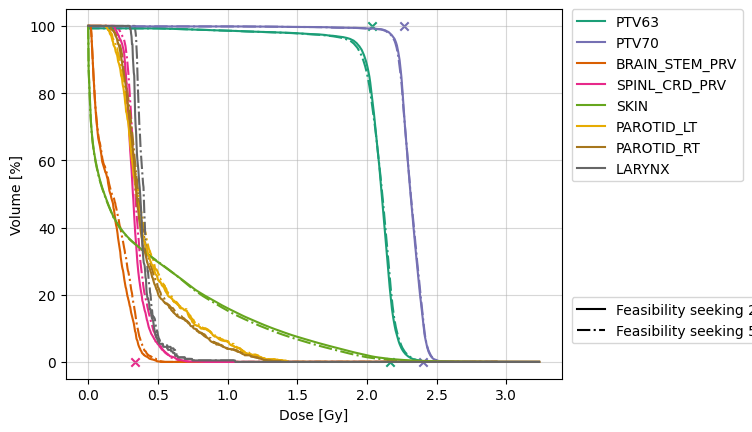

In [30]:
from suppy.utils import calc_dvh
colors = ['#1b9e77','#7570b3','#d95f02','#e7298a','#66a61e','#e6ab02','#a6761d','#666666']

plt.close()
fig,ax = plt.subplots()

a,b = calc_dvh(dij@sol_linear_500.get(), new_idxs)

for i,(el,label) in enumerate(zip(a,organs_c)):
    ax.plot(b,el*100,color = colors[i],linestyle = '-.')



p1 = ax.plot(0,0,label = r'Feasibility seeking 2500', color = 'k',linestyle = '-')
p3 = ax.plot(0,0,label = r'Feasibility seeking 500', color = 'k',linestyle = '-.')
handles = [p1[0], p3[0]]
legend2 = plt.legend(handles=handles, loc="upper left", bbox_to_anchor=(1.02, 0.02 ,0.3, 0.2), borderaxespad=0)

a,b = calc_dvh(dij@sol_linear_2500.get(), new_idxs)
handles = []
for i,(el,label) in enumerate(zip(a,organs_c)):
    handles.append(ax.plot(b,el*100,color = colors[i],linestyle = '-',label = label)[0])
legend1 = ax.legend(handles=handles, loc="upper left", bbox_to_anchor=(1.02, 0.8, 0.3, 0.2), borderaxespad=0)
ax.add_artist(legend2)


bbox1 = legend1.get_window_extent(fig.canvas.get_renderer())
bbox2 = legend2.get_window_extent(fig.canvas.get_renderer())

max_width = max(bbox1.width, bbox2.width)



#plt.scatter(30,0,marker = 'x',color = colors[2])
#plt.scatter(40,0,marker = 'x',color = colors[3])
plt.scatter(10/frac,0,marker = 'x',color = colors[3])
plt.scatter(65/frac,0,marker = 'x',color = colors[0])
plt.scatter(61/frac,1*100,marker = 'x',color = colors[0])

plt.scatter(68/frac,1*100,marker = 'x',color = colors[1])
plt.scatter(72/frac,0,marker = 'x',color = colors[1])
plt.xlabel('Dose [Gy]')
plt.ylabel('Volume [%]')
plt.grid(alpha = 0.5)


plt.savefig('HN_comparison_DVH_500_2500_linear_feasibility_30_fractions_new_colors.png', bbox_inches='tight', dpi = 600)
#plt.xlim(right = 80)

### DVH comparison for 500 and 2500 iterations linear superiorization

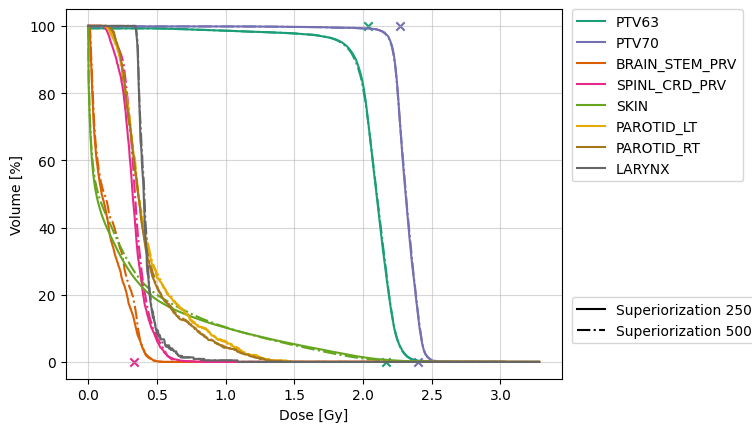

In [31]:
from suppy.utils import calc_dvh
colors = ['#1b9e77','#7570b3','#d95f02','#e7298a','#66a61e','#e6ab02','#a6761d','#666666']

plt.close()
fig,ax = plt.subplots()

a,b = calc_dvh(dij@sol_sup_linear_500.get(), new_idxs)

for i,(el,label) in enumerate(zip(a,organs_c)):
    ax.plot(b,el*100,color = colors[i],linestyle = '-.')



p1 = ax.plot(0,0,label = r'Superiorization 2500', color = 'k',linestyle = '-')
p3 = ax.plot(0,0,label = r'Superiorization 500', color = 'k',linestyle = '-.')
handles = [p1[0], p3[0]]
legend2 = plt.legend(handles=handles, loc="upper left", bbox_to_anchor=(1.02, 0.02 ,0.3, 0.2), borderaxespad=0)

a,b = calc_dvh(dij@sol_sup_linear_2500.get(), new_idxs)
handles = []
for i,(el,label) in enumerate(zip(a,organs_c)):
    handles.append(ax.plot(b,el*100,color = colors[i],linestyle = '-',label = label)[0])
legend1 = ax.legend(handles=handles, loc="upper left", bbox_to_anchor=(1.02, 0.8, 0.3, 0.2), borderaxespad=0)
ax.add_artist(legend2)


bbox1 = legend1.get_window_extent(fig.canvas.get_renderer())
bbox2 = legend2.get_window_extent(fig.canvas.get_renderer())

max_width = max(bbox1.width, bbox2.width)



plt.scatter(10/frac,0,marker = 'x',color = colors[3])
plt.scatter(65/frac,0,marker = 'x',color = colors[0])
plt.scatter(61/frac,1*100,marker = 'x',color = colors[0])

plt.scatter(68/frac,1*100,marker = 'x',color = colors[1])
plt.scatter(72/frac,0,marker = 'x',color = colors[1])

plt.xlabel('Dose [Gy]')
plt.ylabel('Volume [%]')
plt.grid(alpha = 0.5)


plt.savefig('HN_comparison_DVH_500_2500_linear_superiorization_30_fractions_new_colors.png', bbox_inches='tight', dpi = 600)
#plt.xlim(right = 80)

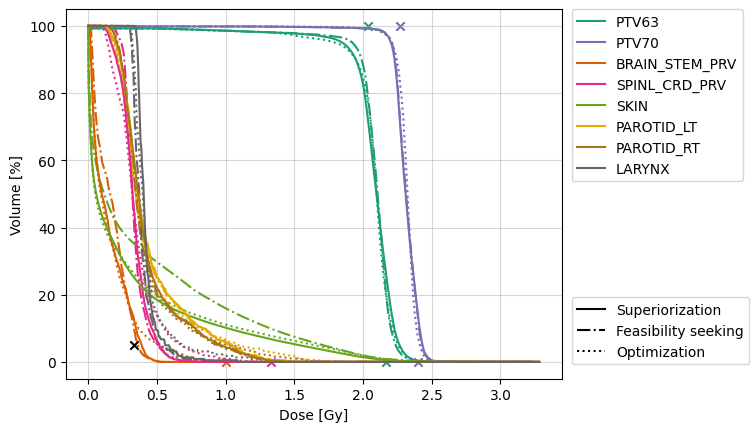

In [32]:
from suppy.utils import calc_dvh
colors = ['#1b9e77','#7570b3','#d95f02','#e7298a','#66a61e','#e6ab02','#a6761d','#666666']
 
fig,ax = plt.subplots()

# MatRad optimized
a,b = calc_dvh(dij@sol_matRad_optimized_comparison, new_idxs)

for i,(el,label) in enumerate(zip(a,organs_c)):
    ax.plot(b,el*100,color = colors[i],linestyle = ':')

# Feasibility seeking
a,b = calc_dvh(dij@sol_linear_2500.get(), new_idxs)

for i,(el,label) in enumerate(zip(a,organs_c)):#
    ax.plot(b,el*100,color = colors[i],linestyle = '-.')



p1 = ax.plot(0,0,label = r'Superiorization', color = 'k',linestyle = '-')
p2 = ax.plot(0,0,label = r'Feasibility seeking', color = 'k',linestyle = '-.')
p3 = ax.plot(0,0,label = r'Optimization', color = 'k',linestyle = ':')
handles = [p1[0], p2[0], p3[0]]
legend2 = plt.legend(handles=handles, loc="upper left", bbox_to_anchor=(1.02, 0.02 ,0.3, 0.2), borderaxespad=0)


a,b = calc_dvh(dij@sol_sup_linear_2500.get(), new_idxs)
handles = []
for i,(el,label) in enumerate(zip(a,organs_c)):
    handles.append(ax.plot(b,el*100,color = colors[i],linestyle = '-',label = label)[0])
legend1 = ax.legend(handles=handles, loc="upper left", bbox_to_anchor=(1.02, 0.8, 0.3, 0.2), borderaxespad=0)
ax.add_artist(legend2)


bbox1 = legend1.get_window_extent(fig.canvas.get_renderer())
bbox2 = legend2.get_window_extent(fig.canvas.get_renderer())

max_width = max(bbox1.width, bbox2.width)


plt.scatter(30/frac,0,marker = 'x',color = colors[2])
plt.scatter(40/frac,0,marker = 'x',color = colors[3])
plt.scatter(65/frac,0,marker = 'x',color = colors[0])
plt.scatter(61/frac,100,marker = 'x',color = colors[0])
plt.scatter(10/frac,5,marker = 'x',color = 'k')
plt.scatter(68/frac,100,marker = 'x',color = colors[1])
plt.scatter(72/frac,0,marker = 'x',color = colors[1])

plt.xlabel('Dose [Gy]')
plt.ylabel('Volume [%]')
plt.grid(alpha = 0.5)


plt.savefig('HN_superiorization_vs_optimization_vs_feasibility_seeking_30_fractions_linear_new_colors.png', bbox_inches='tight', dpi = 600)
#plt.xlim(right = 80)

In [33]:
'#1b9e77';'#d95f02';'#7570b3';'#e7298a';'#66a61e';'#e6ab02';'#a6761d';'#666666'

'#666666'

In [34]:
scipy.io.savemat('HN_solutions_30_fractions.mat', {'sol_500': cp.asnumpy(sol_500.get()),
                                       'sol_2500': cp.asnumpy(sol_2500.get()),
                                        'sol_sup_power_law_500': cp.asnumpy(sol_sup_power_law_500.get()),
                                        'sol_sup_power_law_2500': cp.asnumpy(sol_sup_power_law_2500.get()),
                                        'sol_linear_500': cp.asnumpy(sol_linear_500.get()),
                                        'sol_linear_2500': cp.asnumpy(sol_linear_2500.get()),
                                        'sol_sup_linear_500': cp.asnumpy(sol_sup_linear_500.get()),
                                        'sol_sup_linear_2500': cp.asnumpy(sol_sup_linear_2500.get())})
